# USL-Suspilne Dataset Analysis

Comprehensive analysis of the dataset: duration, splits, outliers, and vocabulary.

**Dependencies:** numpy, matplotlib, pandas

## 1. Load Data

In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve().parent.parent
POSES_DIR = ROOT / "data/usl-suspilne/poses/mediapipe_holistic"
FEATURES_DIR = ROOT / "data/usl-suspilne/features"
FPS = 30.0

SPLIT_DIR = ROOT / "data/usl-suspilne"
SPLITS = ["train", "dev", "test", "test_unseen"]

rows = []
for split_name in SPLITS:
    split_csv = SPLIT_DIR / f"{split_name}.csv"
    if not split_csv.exists():
        print(f"WARNING: {split_csv} not found")
        continue
    with open(split_csv, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f, delimiter="|"):
            name = row["name"]
            vid, clip_id = name.split("/")
            text_norm = row["text_norm"]

            pose_path = POSES_DIR / vid / f"{clip_id}.npy"
            n_frames = np.load(pose_path).shape[0] if pose_path.exists() else 0

            rows.append({
                "name": name,
                "video_id": vid,
                "clip_id": clip_id,
                "text_norm": text_norm,
                "signer_id": row.get("signer_id", ""),
                "n_frames": n_frames,
                "duration_s": n_frames / FPS,
                "n_tokens": len(text_norm.split()),
                "split": split_name,
            })

df = pd.DataFrame(rows)
print(f"Total clips: {len(df)}")
print(f"Total duration: {df['duration_s'].sum() / 3600:.2f} hours")
print(f"Clips with poses: {(df['n_frames'] > 0).sum()}")
df.head()

Total clips: 5133
Total duration: 7.56 hours
Clips with poses: 5079


,name,video_id,clip_id,text_norm,signer_id,n_frames,duration_s,n_tokens,split
0,2Nnz697BVTw/0000,2Nnz697BVTw,0000,інформаційний проєкт суспільна студія повертає...,1,111,3.700000,8,train
1,2Nnz697BVTw/0001,2Nnz697BVTw,0001,зараз передресовуючись ми можемо побачити цими...,1,342,11.400000,18,train
2,2Nnz697BVTw/0002,2Nnz697BVTw,0002,як стало попередньо відомо він завітав на один...,1,282,9.400000,15,train
3,2Nnz697BVTw/0003,2Nnz697BVTw,0003,і зараз наші глядачі можуть побачити промову,1,105,3.500000,7,train
4,2Nnz697BVTw/0004,2Nnz697BVTw,0004,це звернення від дональда трампа,1,77,2.566667,5,train


## 2. Overview by Video & Signer

In [2]:
# Clips per video
video_stats = df.groupby("video_id").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    split=("split", "first"),
    signers=("signer_id", lambda x: ",".join(sorted(set(x)))),
).sort_values("clips", ascending=False)

print(video_stats.to_string())
print(f"\nTotal videos: {len(video_stats)}")

             clips  duration_min        split signers
video_id                                             
d37lwXaSjs4    500     41.392222        train     4,6
IOflFDS2biE    484     34.473333        train     4,6
jj5jiyl2mh0    423     37.103333        train       5
9NMtlqDBY_s    354     27.181111        train       0
VVjY5HVY0jg    347     26.741667        train       0
4FUDnWC9UJA    308     25.340556        train       2
yPYU48eSeBg    291     27.547222        train       0
6O0ZiSgKJNc    245     22.202778          dev     4,6
0ULOz5HM4pA    227     18.403333         test       0
Nyykyn4FpNo    214     19.283333        train     4,6
g5Az2FHUQBU    185     14.992222        train       0
eYEK-n2alOA    180     16.019444        train       0
cNT6ajjEwVU    173     22.831667          dev       1
uGMgleLkjho    150     13.271667        train       1
KUDt_SKkPUE    146     16.453889        train       1
Q3yRVXmZdGQ    142     11.367222        train       1
A2hCZVvtUSE    122     15.52

In [3]:
# Clips per signer
signer_stats = df.groupby("signer_id").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    videos=("video_id", "nunique"),
    splits=("split", lambda x: ",".join(sorted(set(x)))),
).sort_values("clips", ascending=False)
print(signer_stats)

           clips  duration_min  videos       splits
signer_id                                          
0           1706    146.414444       7   test,train
6           1012     84.044444       4    dev,train
1            869     94.671667       7    dev,train
4            546     42.325556       5    dev,train
5            494     45.185000       2        train
2            344     29.245556       2   test,train
3            108     11.928889       1  test_unseen
              54      0.000000       1        train


## 3. Split Analysis

In [4]:
split_stats = df.groupby("split").agg(
    clips=("name", "count"),
    hours=("duration_s", lambda x: x.sum() / 3600),
    videos=("video_id", "nunique"),
    avg_tokens=("n_tokens", "mean"),
    avg_duration=("duration_s", "mean"),
).reindex(SPLITS)

split_stats["clip_%"] = split_stats["clips"] / split_stats["clips"].sum() * 100
split_stats["hour_%"] = split_stats["hours"] / split_stats["hours"].sum() * 100

print(split_stats.round(2).to_string())

             clips  hours  videos  avg_tokens  avg_duration  clip_%  hour_%
split                                                                      
train         4344   6.24      20       10.73          5.17   84.63   82.53
dev            418   0.75       2       12.73          6.46    8.14    9.92
test           263   0.37       2       10.47          5.09    5.12    4.92
test_unseen    108   0.20       1       13.97          6.63    2.10    2.63


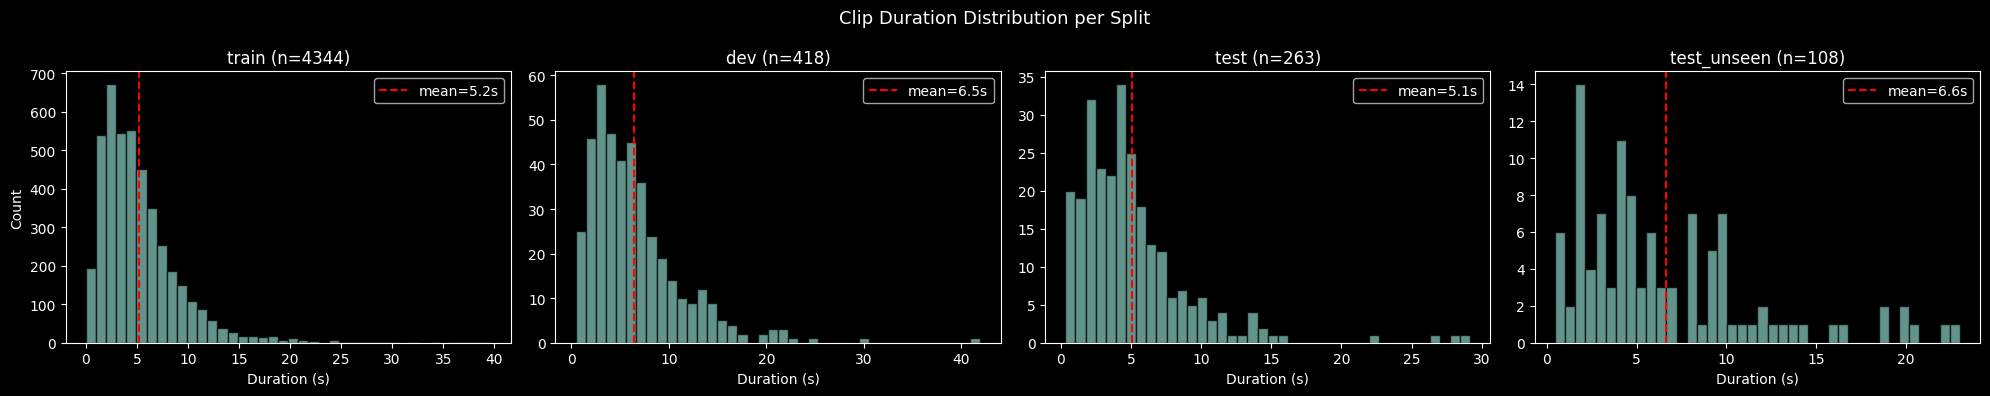

In [5]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 4))

for ax, split in zip(axes, SPLITS):
    subset = df[df["split"] == split]
    ax.hist(subset["duration_s"], bins=40, edgecolor="black", alpha=0.7)
    ax.axvline(subset["duration_s"].mean(), color="red", linestyle="--",
               label=f"mean={subset['duration_s'].mean():.1f}s")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Duration (s)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Clip Duration Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

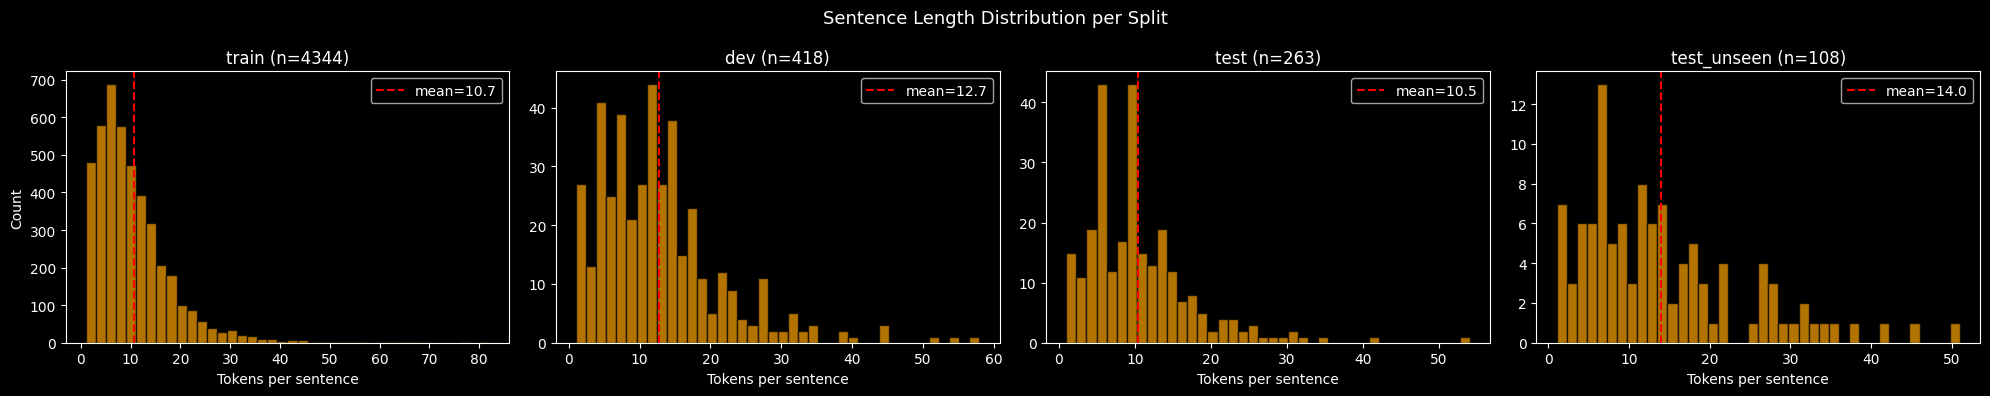

In [6]:
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 4))

for ax, split in zip(axes, SPLITS):
    subset = df[df["split"] == split]
    ax.hist(subset["n_tokens"], bins=40, edgecolor="black", alpha=0.7, color="orange")
    ax.axvline(subset["n_tokens"].mean(), color="red", linestyle="--",
               label=f"mean={subset['n_tokens'].mean():.1f}")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Tokens per sentence")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Sentence Length Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Outlier Detection

We look for clips that may hurt training quality:
- **Very short** (<1s) — not enough motion signal
- **Very long** (>30s) — likely segmentation errors
- **Missing poses** — no pose file extracted
- **Single-token** — filler words like "так", "дякую"
- **Token-rate outliers** — text/duration mismatch (bad alignment)

In [7]:
df["tokens_per_sec"] = df["n_tokens"] / df["duration_s"].replace(0, np.nan)

# Outlier flags
df["flag_short"] = df["duration_s"] < 1.0
df["flag_long"] = df["duration_s"] > 30.0
df["flag_no_pose"] = df["n_frames"] == 0
df["flag_single_tok"] = df["n_tokens"] <= 1
df["flag_high_rate"] = df["tokens_per_sec"] > df["tokens_per_sec"].quantile(0.99)
df["flag_low_rate"] = df["tokens_per_sec"] < df["tokens_per_sec"].quantile(0.01)
df["flag_any"] = df[["flag_short", "flag_long", "flag_no_pose", "flag_single_tok", "flag_high_rate", "flag_low_rate"]].any(axis=1)

outlier_summary = pd.DataFrame({
    "Category": ["< 1s duration", "> 30s duration", "Missing poses", "Single token (0-1)",
                  "Top 1% token rate", "Bottom 1% token rate", "Any flag"],
    "Count": [df["flag_short"].sum(), df["flag_long"].sum(), df["flag_no_pose"].sum(),
              df["flag_single_tok"].sum(), df["flag_high_rate"].sum(), df["flag_low_rate"].sum(),
              df["flag_any"].sum()],
})
outlier_summary["% of dataset"] = (outlier_summary["Count"] / len(df) * 100).round(1)
outlier_summary

,Category,Count,% of dataset
0,< 1s duration,230,4.5
1,> 30s duration,11,0.2
2,Missing poses,54,1.1
3,Single token (0-1),103,2.0
4,Top 1% token rate,51,1.0
5,Bottom 1% token rate,49,1.0
6,Any flag,343,6.7


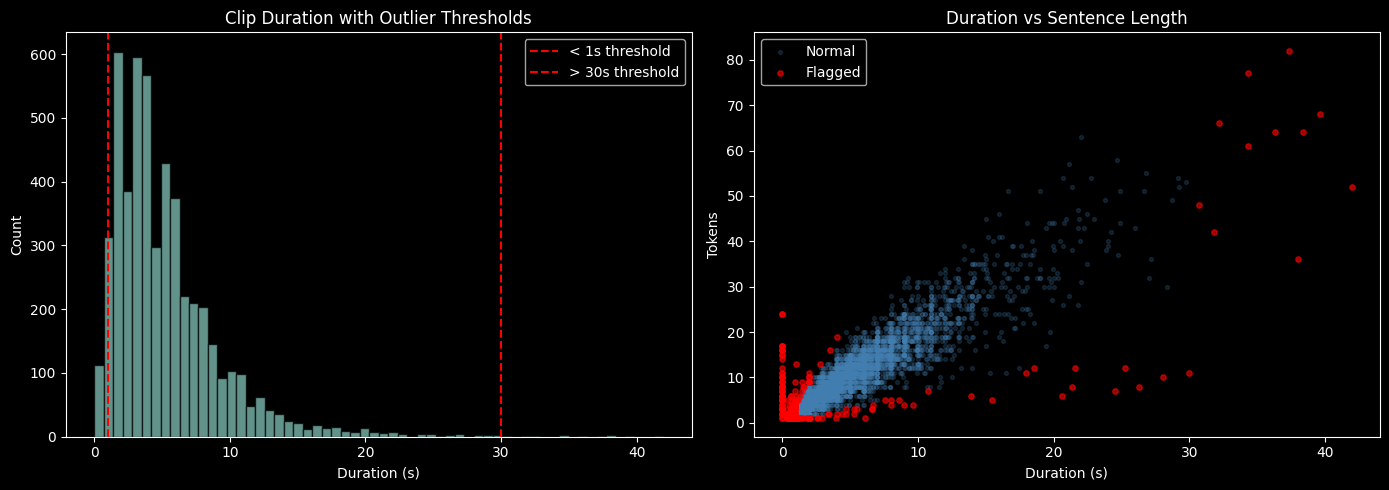

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram with outlier thresholds
ax = axes[0]
ax.hist(df["duration_s"], bins=60, edgecolor="black", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="< 1s threshold")
ax.axvline(30.0, color="red", linestyle="--", linewidth=1.5, label="> 30s threshold")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Clip Duration with Outlier Thresholds")
ax.legend()

# Duration vs token count scatter
ax = axes[1]
normal = df[~df["flag_any"]]
flagged = df[df["flag_any"]]
ax.scatter(normal["duration_s"], normal["n_tokens"], alpha=0.2, s=8, color="steelblue", label="Normal")
ax.scatter(flagged["duration_s"], flagged["n_tokens"], alpha=0.6, s=15, color="red", label="Flagged")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Tokens")
ax.set_title("Duration vs Sentence Length")
ax.legend()

plt.tight_layout()
plt.show()

### 4a. Very short clips (< 1s)

In [9]:
short = df[df["flag_short"]].sort_values("duration_s")
print(f"{len(short)} clips under 1 second")
short[["name", "split", "duration_s", "n_tokens", "text_norm"]].head(15)

230 clips under 1 second


,name,split,duration_s,n_tokens,text_norm
3402,gtFOLKjnays/0047,train,0.0,10,сьогодні о дев'ятий вечора за києвом джо байде...
3384,gtFOLKjnays/0029,train,0.0,9,справа в тому що війна і все що пов'язане
3385,gtFOLKjnays/0030,train,0.0,15,все що пов'язане з війною негативно відображає...
3386,gtFOLKjnays/0031,train,0.0,24,у нас в активному дітеродному віці перебувають...
3387,gtFOLKjnays/0032,train,0.0,7,і це вже відбувається на демографічній ситуації
3388,gtFOLKjnays/0033,train,0.0,9,тому що це вже зменшує кількість народжень зар...
3389,gtFOLKjnays/0034,train,0.0,6,вже має вплив серед інших факторів
3390,gtFOLKjnays/0035,train,0.0,5,тому ми вже відчуваємо те
3391,gtFOLKjnays/0036,train,0.0,3,пов'язано з війною
3392,gtFOLKjnays/0037,train,0.0,3,зниження мобілізаційного об'єкту


### 4b. Very long clips (> 30s)

In [10]:
long = df[df["flag_long"]].sort_values("duration_s", ascending=False)
print(f"{len(long)} clips over 30 seconds")
long[["name", "split", "duration_s", "n_tokens", "text_norm"]]

11 clips over 30 seconds


,name,split,duration_s,n_tokens,text_norm
4626,cNT6ajjEwVU/0037,dev,41.966667,52,двадцять другий рік багато в двадцять третьому...
4312,yPYU48eSeBg/0260,train,39.633333,68,так на жаль ми бачимо зміну в риториці америка...
1521,KUDt_SKkPUE/0112,train,38.366667,64,от звісно якщо до нашої роботи власне буде пов...
3704,jj5jiyl2mh0/0295,train,38.000000,36,не евакуювалися з міста ситуація в місті вкрай...
793,A2hCZVvtUSE/0046,train,37.366667,82,зараз буде дуже суб'єктивна моя оцінка не треб...
2927,d37lwXaSjs4/0438,train,36.300000,64,якраз щодо розпорошеної генерації яка була зір...
796,A2hCZVvtUSE/0049,train,34.366667,77,так він чудово мабуть розуміє що це насправді ...
4204,yPYU48eSeBg/0152,train,34.300000,61,скажуть артисти що для них важливо відроджуват...
79,2Nnz697BVTw/0079,train,32.233333,66,і ось цим ми зараз теж займаємось я нещодавно ...
74,2Nnz697BVTw/0074,train,31.800000,42,якщо діаспора проживає на тихоокеанському узбе...


### 4c. Missing poses & single-token clips

In [11]:
missing = df[df["flag_no_pose"]]
print(f"Missing poses: {len(missing)}")
if len(missing) > 0:
    display(missing[["name", "split", "n_tokens", "text_norm"]])

print(f"\nSingle-token clips: {df['flag_single_tok'].sum()}")
single = df[df["flag_single_tok"]]
single_words = Counter(single["text_norm"])
print("\nMost common single-token texts:")
for word, count in single_words.most_common(15):
    print(f"  {word:<20} {count:>3}x")

Missing poses: 54


,name,split,n_tokens,text_norm
3355,gtFOLKjnays/0000,train,4,триває ефір суспільне студія
3356,gtFOLKjnays/0001,train,8,сьогодні ввечері для вас працюємо інна і єрема
3357,gtFOLKjnays/0002,train,3,жестова мова журкова
3358,gtFOLKjnays/0003,train,5,і продовжуємо обговорення наших тем
3359,gtFOLKjnays/0004,train,5,україна має знизити мобілізаційний вік
3360,gtFOLKjnays/0005,train,11,майбутній радник президента сша з питань нацбе...
3361,gtFOLKjnays/0006,train,10,зараз вони прозивають із двадцять шість років ...
3362,gtFOLKjnays/0007,train,14,мені здається багато людей не розуміють що вон...
3363,gtFOLKjnays/0008,train,9,ми чуємо про моральні проблеми про проблеми на...
3364,gtFOLKjnays/0009,train,16,слухайте якщо українці просять весь світ піти ...



Single-token clips: 103

Most common single-token texts:
  так                   13x
  дякую                 10x
  зрозуміло              8x
  вітаю                  5x
  послухаймо             3x
  угу                    3x
  вітаємо                3x
  дякуємо                3x
  ділиться               2x
  ні                     2x
  чому                   2x
  добре                  2x
  дивіться               2x
  послухаємо             2x
  ну                     1x


### 4d. Token-rate outliers (text ↔ duration mismatch)

In [12]:
print("Token rate (tokens/sec) percentiles:")
print(df["tokens_per_sec"].describe().round(2).to_string())

print(f"\n--- Top 1% rate (>{df['tokens_per_sec'].quantile(0.99):.1f} tok/s) — text too long for clip duration ---")
high = df[df["flag_high_rate"]].sort_values("tokens_per_sec", ascending=False)
display(high[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text_norm"]].head(10))

print(f"\n--- Bottom 1% rate (<{df['tokens_per_sec'].quantile(0.01):.1f} tok/s) — clip too long for text ---")
low = df[df["flag_low_rate"]].sort_values("tokens_per_sec")
display(low[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text_norm"]].head(10))

Token rate (tokens/sec) percentiles:
count    5079.00
mean        2.20
std         0.74
min         0.16
25%         1.76
50%         2.14
75%         2.54
max        13.00

--- Top 1% rate (>4.4 tok/s) — text too long for clip duration ---


,name,split,duration_s,n_tokens,tokens_per_sec,text_norm
1292,IOflFDS2biE/0423,train,1.000000,13,13.000000,вітаємо що він потім відуть подолу і вийде на ...
2571,d37lwXaSjs4/0081,train,0.433333,5,11.538462,каже що вона не виглядає
702,9NMtlqDBY_s/0309,train,0.966667,9,9.310345,в перші десятиліття українська база була відді...
1190,IOflFDS2biE/0321,train,0.666667,6,9.000000,він це дуже важливий для мене
2008,Q3yRVXmZdGQ/0122,train,0.666667,6,9.000000,листопада дві тисячі двадцять три року
2882,d37lwXaSjs4/0392,train,0.366667,3,8.181818,і за що
2214,VVjY5HVY0jg/0071,train,0.500000,4,8.000000,дмитро масловський чотири клас
4929,0ULOz5HM4pA/0167,test,0.633333,5,7.894737,перекладач жестової мови ольга крот
5106,82dy0zC6X_8/0082,test_unseen,0.966667,7,7.241379,тому це реальність від якої треба виштовхуватись
2079,S0o1oJ6G5qw/0051,train,0.300000,2,6.666667,доброго дня



--- Bottom 1% rate (<0.7 tok/s) — clip too long for text ---


,name,split,duration_s,n_tokens,tokens_per_sec,text_norm
1527,KUDt_SKkPUE/0118,train,6.066667,1,0.164835,жодного
4430,6O0ZiSgKJNc/0090,dev,3.933333,1,0.254237,аналітика
2674,d37lwXaSjs4/0184,train,24.500000,7,0.285714,ефір на суспільному продовжує команда суспільн...
4235,yPYU48eSeBg/0183,train,20.600000,6,0.291262,отже триває інформаційний вечір на суспільному
686,9NMtlqDBY_s/0293,train,26.266667,8,0.304569,звичайно для харкова це була надзвичайно важли...
4442,6O0ZiSgKJNc/0102,dev,15.466667,5,0.323276,суспільне новини о дев'ятнадцять тій
5061,82dy0zC6X_8/0037,test_unseen,2.966667,1,0.337079,так
4979,0ULOz5HM4pA/0217,test,28.066667,10,0.356295,а якщо він наприклад находиться територіально ...
4671,cNT6ajjEwVU/0083,dev,29.966667,11,0.367075,бригади обіцяють підтримку та консультації на ...
720,9NMtlqDBY_s/0327,train,21.333333,8,0.375000,від шістдесятих до вісімдесятих радіо досягло ...


### 4e. Impact of removing flagged clips

In [13]:
clean = df[~df["flag_any"]]
print(f"Before filtering: {len(df):>5} clips, {df['duration_s'].sum()/3600:.2f}h")
print(f"After filtering:  {len(clean):>5} clips, {clean['duration_s'].sum()/3600:.2f}h")
print(f"Removed:          {len(df)-len(clean):>5} clips, {(df['duration_s'].sum()-clean['duration_s'].sum())/3600:.2f}h")
print()

for split in SPLITS:
    before = df[df["split"] == split]
    after = clean[clean["split"] == split]
    print(f"  {split}: {len(before)} → {len(after)} clips "
          f"({before['duration_s'].sum()/3600:.2f}h → {after['duration_s'].sum()/3600:.2f}h)")

Before filtering:  5133 clips, 7.56h
After filtering:   4790 clips, 7.28h
Removed:            343 clips, 0.29h

  train: 4344 → 4057 clips (6.24h → 6.01h)
  dev: 418 → 390 clips (0.75h → 0.71h)
  test: 263 → 242 clips (0.37h → 0.36h)
  test_unseen: 108 → 101 clips (0.20h → 0.20h)


## 5. Vocabulary & OOV

In [14]:
# Vocabulary and OOV
eval_splits = [s for s in SPLITS if s != "train"]

split_tokens = {s: [t for text in df[df["split"] == s]["text_norm"] for t in text.split()] for s in SPLITS}
train_vocab = set(split_tokens["train"])

print(f"{'Split':<14} {'Tokens':>8} {'Types':>7}")
print("-" * 34)
for s in SPLITS:
    types = len(set(split_tokens[s]))
    print(f"{s:<14} {len(split_tokens[s]):>8} {types:>7}")

print(f"\n{'Split':<14} {'OOV tokens':>11} {'OOV %':>7} {'OOV types':>10} {'OOV type %':>11}")
print("-" * 58)
for s in eval_splits:
    tokens = split_tokens[s]
    types = set(tokens)
    oov_tokens = [t for t in tokens if t not in train_vocab]
    oov_types = types - train_vocab
    print(f"{s:<14} {len(oov_tokens):>11} {len(oov_tokens)/max(len(tokens),1)*100:>6.1f}% "
          f"{len(oov_types):>10} {len(oov_types)/max(len(types),1)*100:>10.1f}%")

train_tokens_all = split_tokens["train"]

Split            Tokens   Types
----------------------------------
train             46625   10870
dev                5323    2306
test               2753    1430
test_unseen        1509     717

Split           OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------------
dev                    778   14.6%        659       28.6%
test                   218    7.9%        196       13.7%
test_unseen            292   19.4%        235       32.8%


### Frequency distribution & Zipf

In [15]:
train_counter = Counter(train_tokens_all)
vocab_size = len(train_counter)
total_tokens = sum(train_counter.values())

print(f"Train vocabulary: {vocab_size} types, {total_tokens} tokens")
print()

# Frequency buckets
freq_buckets = {"1": 0, "2": 0, "3-5": 0, "6-10": 0, "11-50": 0, "51+": 0}
for word, count in train_counter.items():
    if count == 1:
        freq_buckets["1"] += 1
    elif count == 2:
        freq_buckets["2"] += 1
    elif count <= 5:
        freq_buckets["3-5"] += 1
    elif count <= 10:
        freq_buckets["6-10"] += 1
    elif count <= 50:
        freq_buckets["11-50"] += 1
    else:
        freq_buckets["51+"] += 1

print(f"{'Frequency':<12} {'Types':>7} {'% of vocab':>10}")
print("-" * 32)
for bucket, count in freq_buckets.items():
    print(f"{bucket:<12} {count:>7} {count / vocab_size * 100:>9.1f}%")

hapax = freq_buckets["1"]
print(f"\nHapax legomena: {hapax} / {vocab_size} = {hapax / vocab_size * 100:.1f}% of vocabulary")

Train vocabulary: 10870 types, 46625 tokens

Frequency      Types % of vocab
--------------------------------
1               6056      55.7%
2               1957      18.0%
3-5             1618      14.9%
6-10             658       6.1%
11-50            486       4.5%
51+               95       0.9%

Hapax legomena: 6056 / 10870 = 55.7% of vocabulary


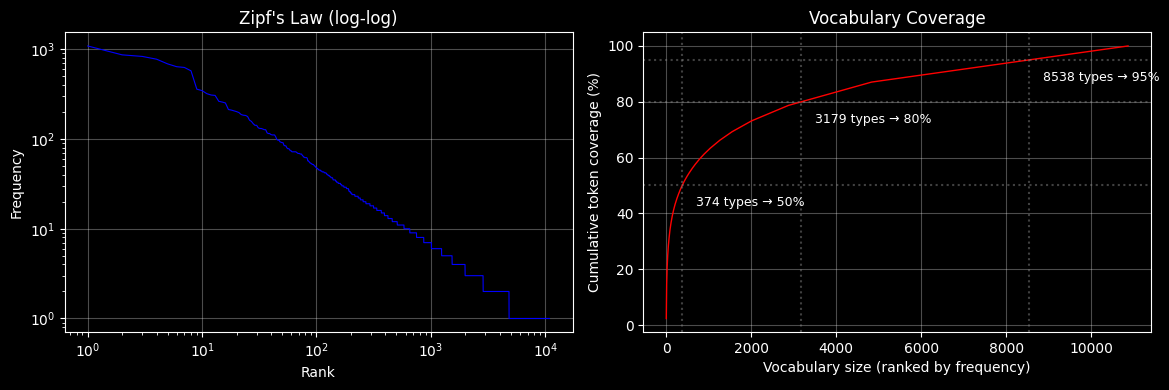

In [16]:
# Zipf's law + cumulative coverage
sorted_counts = sorted(train_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ranks, sorted_counts, "b-", linewidth=0.8)
ax1.set_xlabel("Rank")
ax1.set_ylabel("Frequency")
ax1.set_title("Zipf's Law (log-log)")
ax1.grid(True, alpha=0.3)

cumsum = np.cumsum(sorted_counts) / sum(sorted_counts) * 100
ax2.plot(ranks, cumsum, "r-", linewidth=1)
for pct in [50, 80, 95]:
    idx = np.searchsorted(cumsum, pct)
    ax2.axhline(pct, color="gray", linestyle=":", alpha=0.5)
    ax2.axvline(idx, color="gray", linestyle=":", alpha=0.5)
    ax2.annotate(f"{idx} types → {pct}%", (idx, pct),
                 textcoords="offset points", xytext=(10, -15), fontsize=9)
ax2.set_xlabel("Vocabulary size (ranked by frequency)")
ax2.set_ylabel("Cumulative token coverage (%)")
ax2.set_title("Vocabulary Coverage")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary

In [17]:
print("=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} clips, {df['duration_s'].sum()/3600:.2f} hours")
print(f"Videos: {df['video_id'].nunique()}")
print(f"Signers: {df['signer_id'].nunique()}")
print()

for split in SPLITS:
    s = df[df["split"] == split]
    print(f"{split:>12}: {len(s):>5} clips, {s['duration_s'].sum()/3600:.2f}h, "
          f"{s['video_id'].nunique()} videos, avg {s['duration_s'].mean():.1f}s/clip")

print(f"\n--- Potential issues ---")
print(f"Clips <1s: {len(df[df['duration_s'] < 1.0])}")
print(f"Clips >30s: {len(df[df['duration_s'] > 30.0])}")
print(f"Missing poses: {len(df[df['n_frames'] == 0])}")
print(f"Single-token clips: {len(df[df['n_tokens'] <= 1])}")

  SUMMARY

Dataset: 5133 clips, 7.56 hours
Videos: 25
Signers: 8

       train:  4344 clips, 6.24h, 20 videos, avg 5.2s/clip
         dev:   418 clips, 0.75h, 2 videos, avg 6.5s/clip
        test:   263 clips, 0.37h, 2 videos, avg 5.1s/clip
 test_unseen:   108 clips, 0.20h, 1 videos, avg 6.6s/clip

--- Potential issues ---
Clips <1s: 230
Clips >30s: 11
Missing poses: 54
Single-token clips: 103
